# MAX30102 Log Analysis (RAW LOGGER)

Notebook này kiểm tra nhanh luồng dữ liệu từ firmware logger:
- Đọc file log CSV từ ESP32
- Parse và làm sạch dữ liệu
- Plot tín hiệu IR/RED/power theo thời gian
- Cắt window 8s, stride 2s
- Trích feature theo cùng style với `ppg_dalia.ipynb`
- Đánh giá phân bố feature và độ ổn định sơ bộ

In [1]:
import sys
import subprocess

REQUIRED_PACKAGES = [
    "numpy",
    "pandas",
    "matplotlib",
    "scipy",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *REQUIRED_PACKAGES])
print("✅ Packages ready")

✅ Packages ready


In [2]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal
from scipy.signal import butter, filtfilt, welch, find_peaks

print("Python:", sys.version.split()[0])
print("CWD:", os.getcwd())

Python: 3.11.9
CWD: c:\ml\kaggle-ml-basics


In [20]:
# Quét log cho thí nghiệm v1 2-state: fixed_50, fixed_100, adaptive
LOG_DIR = Path(r"C:/ml/kaggle-ml-basics/log/exp_v1_2state")

assert LOG_DIR.exists(), f"Không tìm thấy thư mục log: {LOG_DIR}"
FILE_RE = re.compile(r"^profile_(?P<profile_name>.+?)_(?P<condition>good|bad)_(?P<run_idx>\d+)\.csv$")

records = []
for fp in sorted(LOG_DIR.rglob("profile_*_*.csv")):
    m = FILE_RE.match(fp.name)
    if m is None:
        continue

    exp_mode = fp.parent.name.lower()  # adaptive | fixed_50 | fixed_100
    if exp_mode not in {"adaptive", "fixed_50", "fixed_100"}:
        continue

    records.append({
        "file_path": fp,
        "file_name": fp.name,
        "profile_name": m.group("profile_name"),
        "condition": m.group("condition"),
        "run_idx": int(m.group("run_idx")),
        "exp_mode": exp_mode,
        "group_dir": fp.parent.name,
    })

experiment_df = pd.DataFrame(records).sort_values(["exp_mode", "condition", "run_idx"]).reset_index(drop=True)
assert len(experiment_df) > 0, "Không tìm thấy file đúng format trong thư mục exp_v1_2state"

print("Found experiment files:", len(experiment_df))
display(experiment_df)

expected_runs = experiment_df.groupby(["exp_mode", "condition"]).size().rename("n_runs").reset_index()
print("\nRun count per mode-condition:")
display(expected_runs)

Found experiment files: 18


,file_path,file_name,profile_name,condition,run_idx,exp_mode,group_dir
0,C:\ml\kaggle-ml-basics\log\exp_v1_2state\adapt...,profile_adaptive_50_100_bad_01.csv,adaptive_50_100,bad,1,adaptive,adaptive
1,C:\ml\kaggle-ml-basics\log\exp_v1_2state\adapt...,profile_adaptive_50_100_bad_02.csv,adaptive_50_100,bad,2,adaptive,adaptive
2,C:\ml\kaggle-ml-basics\log\exp_v1_2state\adapt...,profile_adaptive_50_100_bad_03.csv,adaptive_50_100,bad,3,adaptive,adaptive
3,C:\ml\kaggle-ml-basics\log\exp_v1_2state\adapt...,profile_adaptive_50_100_good_01.csv,adaptive_50_100,good,1,adaptive,adaptive
4,C:\ml\kaggle-ml-basics\log\exp_v1_2state\adapt...,profile_adaptive_50_100_good_02.csv,adaptive_50_100,good,2,adaptive,adaptive
5,C:\ml\kaggle-ml-basics\log\exp_v1_2state\adapt...,profile_adaptive_50_100_good_03.csv,adaptive_50_100,good,3,adaptive,adaptive
6,C:\ml\kaggle-ml-basics\log\exp_v1_2state\fixed...,profile_100sps_med_bad_01.csv,100sps_med,bad,1,fixed_100,fixed_100
7,C:\ml\kaggle-ml-basics\log\exp_v1_2state\fixed...,profile_100sps_med_bad_02.csv,100sps_med,bad,2,fixed_100,fixed_100
8,C:\ml\kaggle-ml-basics\log\exp_v1_2state\fixed...,profile_100sps_med_bad_03.csv,100sps_med,bad,3,fixed_100,fixed_100
9,C:\ml\kaggle-ml-basics\log\exp_v1_2state\fixed...,profile_100sps_med_good_01.csv,100sps_med,good,1,fixed_100,fixed_100



Run count per mode-condition:


,exp_mode,condition,n_runs
0,adaptive,bad,3
1,adaptive,good,3
2,fixed_100,bad,3
3,fixed_100,good,3
4,fixed_50,bad,3
5,fixed_50,good,3


In [21]:
def parse_logger_file(path: Path):
    rows = []
    total_lines = 0
    matched_lines = 0

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            total_lines += 1
            s = line.strip()
            if not s or s.startswith("I (") or "SYS_DEMO:" in s:
                continue

            parts = s.split(",")
            if len(parts) == 7:
                try:
                    rows.append({
                        "timestamp_ms": int(parts[0]),
                        "state_id": -1,
                        "profile_id": int(parts[1]),
                        "quality_pass": np.nan,
                        "difficulty_proxy": np.nan,
                        "red": int(parts[2]),
                        "ir": int(parts[3]),
                        "bus_v": float(parts[4]),
                        "current_ma": float(parts[5]),
                        "power_mw": float(parts[6]),
                    })
                    matched_lines += 1
                except ValueError:
                    continue
            elif len(parts) == 10:
                try:
                    rows.append({
                        "timestamp_ms": int(parts[0]),
                        "state_id": int(parts[1]),
                        "profile_id": int(parts[2]),
                        "quality_pass": int(parts[3]),
                        "difficulty_proxy": float(parts[4]),
                        "red": int(parts[5]),
                        "ir": int(parts[6]),
                        "bus_v": float(parts[7]),
                        "current_ma": float(parts[8]),
                        "power_mw": float(parts[9]),
                    })
                    matched_lines += 1
                except ValueError:
                    continue

    df = pd.DataFrame(rows)
    if len(df) == 0:
        raise ValueError(f"Không parse được dòng CSV nào từ file: {path}")

    df = df.sort_values("timestamp_ms").drop_duplicates(subset=["timestamp_ms"], keep="last").reset_index(drop=True)
    df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0
    df["dt_s"] = df["time_s"].diff().fillna(0.0)
    return df, total_lines, matched_lines

all_raw_parts = []
file_stats = []

for _, row in experiment_df.iterrows():
    df_one, total_lines, matched_lines = parse_logger_file(Path(row["file_path"]))
    dt = df_one["dt_s"].values
    dt = dt[dt > 1e-6]
    fs_est = 1.0 / np.median(dt) if len(dt) else np.nan

    df_one["file_name"] = row["file_name"]
    df_one["profile_name"] = row["profile_name"]
    df_one["condition"] = row["condition"]
    df_one["run_idx"] = row["run_idx"]
    df_one["exp_mode"] = row["exp_mode"]
    all_raw_parts.append(df_one)

    file_stats.append({
        "file_name": row["file_name"],
        "exp_mode": row["exp_mode"],
        "profile_name": row["profile_name"],
        "condition": row["condition"],
        "run_idx": row["run_idx"],
        "rows_raw": len(df_one),
        "duration_s": float(df_one["time_s"].iloc[-1]),
        "fs_est_hz": float(fs_est) if np.isfinite(fs_est) else np.nan,
        "matched_csv_rows": matched_lines,
        "total_lines": total_lines,
        "profile_ids_in_file": ",".join(map(str, sorted(df_one["profile_id"].unique().tolist()))),
        "state_ids_in_file": ",".join(map(str, sorted(df_one["state_id"].dropna().astype(int).unique().tolist()))),
    })

raw_df = pd.concat(all_raw_parts, ignore_index=True)
file_stats_df = pd.DataFrame(file_stats).sort_values(["exp_mode", "condition", "run_idx"]).reset_index(drop=True)

print("Total rows across all files:", len(raw_df))
display(file_stats_df)
display(raw_df.head())

Total rows across all files: 40830


,file_name,exp_mode,profile_name,condition,run_idx,rows_raw,duration_s,fs_est_hz,matched_csv_rows,total_lines,profile_ids_in_file,state_ids_in_file
0,profile_adaptive_50_100_bad_01.csv,adaptive,adaptive_50_100,bad,1,2263,90.491,25.0,2263,2263,2,0
1,profile_adaptive_50_100_bad_02.csv,adaptive,adaptive_50_100,bad,2,2299,92.112,25.0,2299,2301,"0,2","0,1"
2,profile_adaptive_50_100_bad_03.csv,adaptive,adaptive_50_100,bad,3,2262,90.451,25.0,2262,2262,2,0
3,profile_adaptive_50_100_good_01.csv,adaptive,adaptive_50_100,good,1,2257,90.352,25.0,2257,2258,"0,2","0,1"
4,profile_adaptive_50_100_good_02.csv,adaptive,adaptive_50_100,good,2,2259,90.423,25.0,2259,2260,"0,2","0,1"
5,profile_adaptive_50_100_good_03.csv,adaptive,adaptive_50_100,good,3,2259,90.431,25.0,2259,2326,"0,2","0,1"
6,profile_100sps_med_bad_01.csv,fixed_100,100sps_med,bad,1,2286,91.426,25.0,2286,2286,0,1
7,profile_100sps_med_bad_02.csv,fixed_100,100sps_med,bad,2,2264,90.554,25.0,2264,2264,0,1
8,profile_100sps_med_bad_03.csv,fixed_100,100sps_med,bad,3,2278,91.092,25.0,2278,2278,0,1
9,profile_100sps_med_good_01.csv,fixed_100,100sps_med,good,1,2263,90.524,25.0,2263,2263,0,1


,timestamp_ms,state_id,profile_id,quality_pass,difficulty_proxy,red,ir,bus_v,current_ma,power_mw,time_s,dt_s,file_name,profile_name,condition,run_idx,exp_mode
0,190,0,2,1,0.5,72640,78885,3.264,3.3,10.771,0.00,0.00,profile_adaptive_50_100_bad_01.csv,adaptive_50_100,bad,1,adaptive
1,230,0,2,1,0.5,78382,91013,3.264,3.3,10.771,0.04,0.04,profile_adaptive_50_100_bad_01.csv,adaptive_50_100,bad,1,adaptive
2,270,0,2,1,0.5,78329,90810,3.248,4.7,15.266,0.08,0.04,profile_adaptive_50_100_bad_01.csv,adaptive_50_100,bad,1,adaptive
3,310,0,2,1,0.5,78203,90526,3.248,4.7,15.266,0.12,0.04,profile_adaptive_50_100_bad_01.csv,adaptive_50_100,bad,1,adaptive
4,350,0,2,1,0.5,77969,89916,3.248,4.7,15.266,0.16,0.04,profile_adaptive_50_100_bad_01.csv,adaptive_50_100,bad,1,adaptive


=== Per-file sampling summary ===


,file_name,profile_name,condition,rows_raw,duration_s,fs_est_hz,profile_ids_in_file,state_ids_in_file
0,profile_adaptive_50_100_bad_01.csv,adaptive_50_100,bad,2263,90.491,25.0,2,0
1,profile_adaptive_50_100_bad_02.csv,adaptive_50_100,bad,2299,92.112,25.0,"0,2","0,1"
2,profile_adaptive_50_100_bad_03.csv,adaptive_50_100,bad,2262,90.451,25.0,2,0
3,profile_adaptive_50_100_good_01.csv,adaptive_50_100,good,2257,90.352,25.0,"0,2","0,1"
4,profile_adaptive_50_100_good_02.csv,adaptive_50_100,good,2259,90.423,25.0,"0,2","0,1"
5,profile_adaptive_50_100_good_03.csv,adaptive_50_100,good,2259,90.431,25.0,"0,2","0,1"
6,profile_100sps_med_bad_01.csv,100sps_med,bad,2286,91.426,25.0,0,1
7,profile_100sps_med_bad_02.csv,100sps_med,bad,2264,90.554,25.0,0,1
8,profile_100sps_med_bad_03.csv,100sps_med,bad,2278,91.092,25.0,0,1
9,profile_100sps_med_good_01.csv,100sps_med,good,2263,90.524,25.0,0,1



=== Profile-condition summary ===


,profile_name,condition,n_files,duration_mean_s,fs_mean_hz,fs_std_hz
0,100sps_med,bad,3,91.024000,25.0,0.0
1,100sps_med,good,3,90.034333,25.0,0.0
2,50sps_med,bad,3,90.514000,25.0,0.0
3,50sps_med,good,3,91.345333,25.0,0.0
4,adaptive_50_100,bad,3,91.018000,25.0,0.0
5,adaptive_50_100,good,3,90.402000,25.0,0.0


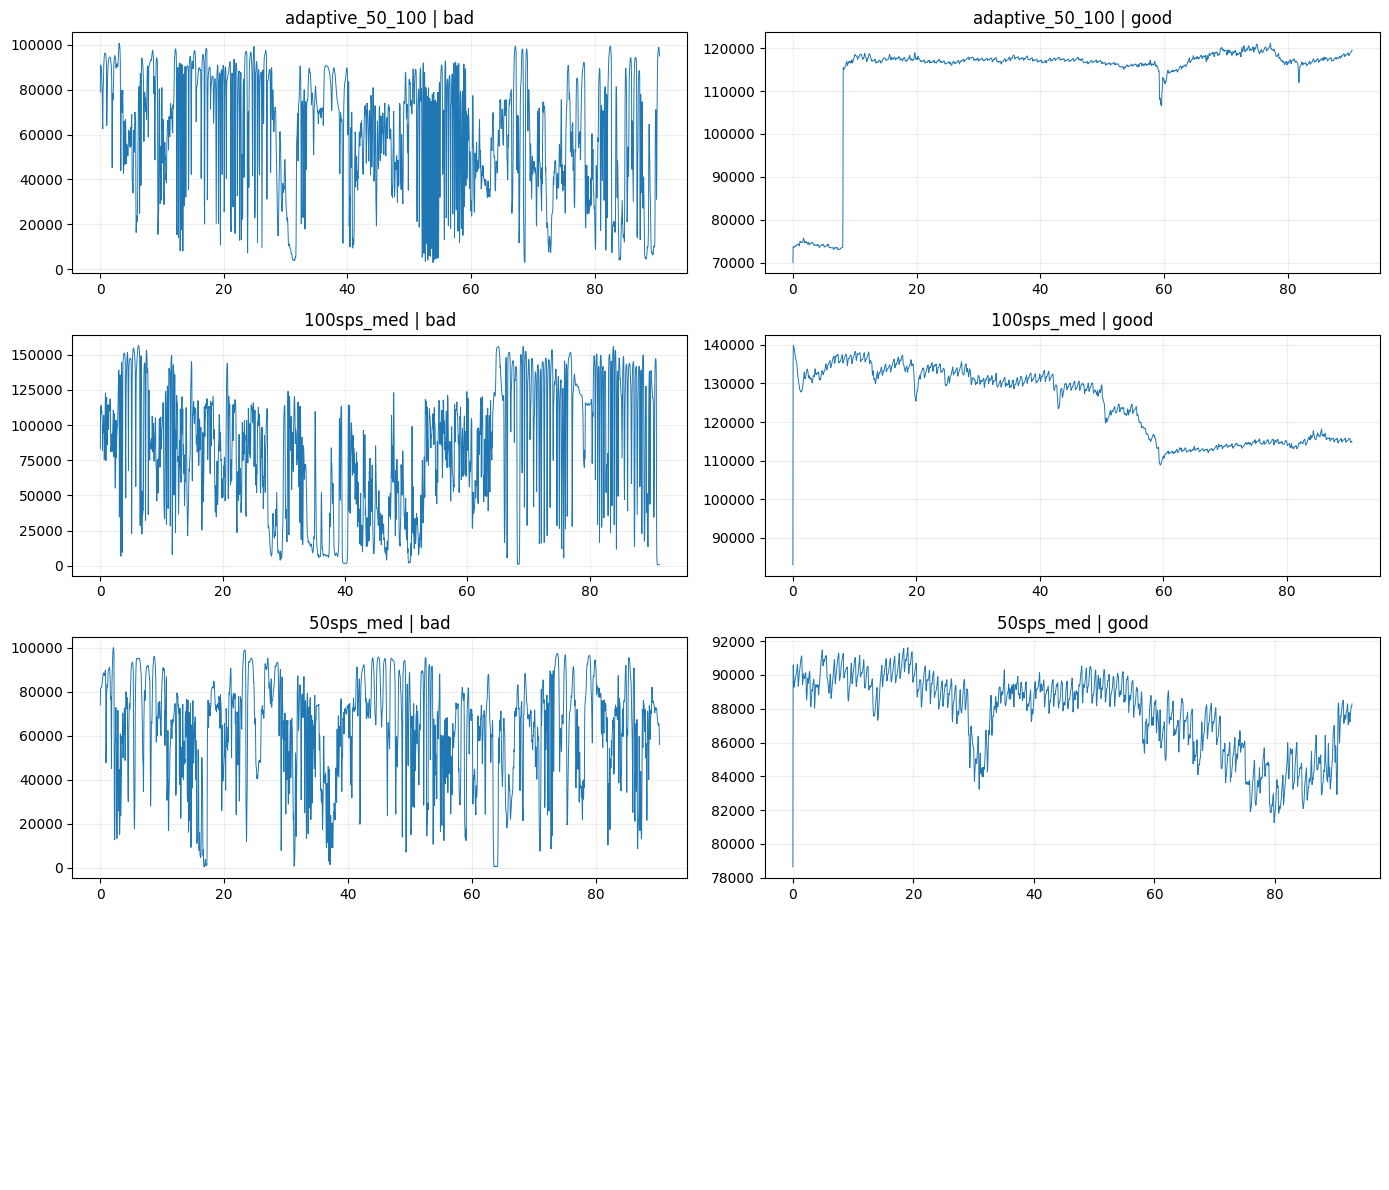

In [22]:
print("=== Per-file sampling summary ===")
display(file_stats_df[["file_name", "profile_name", "condition", "rows_raw", "duration_s", "fs_est_hz", "profile_ids_in_file", "state_ids_in_file"]])

summary_by_profile = file_stats_df.groupby(["profile_name", "condition"]).agg(
    n_files=("file_name", "count"),
    duration_mean_s=("duration_s", "mean"),
    fs_mean_hz=("fs_est_hz", "mean"),
    fs_std_hz=("fs_est_hz", "std"),
).reset_index()

print("\n=== Profile-condition summary ===")
display(summary_by_profile)

# Plot quick-look cho 1 file đại diện mỗi profile x condition
fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=False)
axes = axes.ravel()
pairs = file_stats_df[["profile_name", "condition"]].drop_duplicates().values.tolist()

for idx, (profile_name, condition) in enumerate(pairs[:len(axes)]):
    rep_file = file_stats_df[(file_stats_df["profile_name"] == profile_name) & (file_stats_df["condition"] == condition)].iloc[0]["file_name"]
    df_rep = raw_df[raw_df["file_name"] == rep_file]
    ax = axes[idx]
    ax.plot(df_rep["time_s"], df_rep["ir"], linewidth=0.7)
    ax.set_title(f"{profile_name} | {condition}")
    ax.grid(alpha=0.2)

for j in range(len(pairs), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [23]:
def safe_nan_to_num(x):
    x = np.asarray(x, dtype=np.float32)
    return np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

def detrend_signal(x):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < 3:
        return x.copy()
    return signal.detrend(x).astype(np.float32)

def butter_bandpass_filter(x, fs, lowcut=0.7, highcut=5.0, order=3):
    x = np.asarray(x, dtype=np.float32)
    nyq = 0.5 * fs
    low = max(0.001, lowcut / nyq)
    high = min(0.99, highcut / nyq)
    if low >= high:
        return x.copy()
    b, a = butter(order, [low, high], btype="band")
    if len(x) < max(len(a), len(b)) * 3:
        return x.copy()
    return filtfilt(b, a, x).astype(np.float32)

def robust_zscore(x):
    x = np.asarray(x, dtype=np.float32)
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    scale = 1.4826 * mad
    if scale < 1e-8:
        scale = np.std(x)
    if scale < 1e-8:
        scale = 1.0
    return ((x - med) / scale).astype(np.float32)

def preprocess_ppg(sig, fs):
    x_raw = safe_nan_to_num(sig)
    x_dt = detrend_signal(x_raw)
    x_bp = butter_bandpass_filter(x_dt, fs=fs, lowcut=0.7, highcut=5.0, order=3)
    x_norm = robust_zscore(x_bp)
    return x_raw, x_dt, x_bp, x_norm

def normalized_autocorr(x):
    x = np.asarray(x, dtype=np.float32)
    x = x - np.mean(x)
    denom = np.sum(x * x)
    if denom < 1e-8:
        return np.zeros(len(x), dtype=np.float32)
    ac = np.correlate(x, x, mode="full")
    ac = ac[len(x)-1:] / denom
    return ac.astype(np.float32)

def spectral_entropy_from_psd(psd):
    psd = np.asarray(psd, dtype=np.float64)
    psd = np.maximum(psd, 1e-12)
    psd = psd / np.sum(psd)
    return float(-np.sum(psd * np.log(psd)) / np.log(len(psd)))

def bandpower(freqs, psd, fmin, fmax):
    mask = (freqs >= fmin) & (freqs <= fmax)
    if np.sum(mask) == 0:
        return 0.0
    integrator = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
    return float(integrator(psd[mask], freqs[mask]))

def extract_ppg_features(sig_raw, fs):
    _, _, _, x = preprocess_ppg(sig_raw, fs)
    n = len(x)
    feats = {}

    dx = np.diff(x)
    feats["mean"] = float(np.mean(x))
    feats["std"] = float(np.std(x))
    feats["ptp"] = float(np.ptp(x))
    feats["rms"] = float(np.sqrt(np.mean(x**2)))
    feats["abs_mean"] = float(np.mean(np.abs(x)))
    feats["slope_abs_mean"] = float(np.mean(np.abs(dx))) if len(dx) > 0 else 0.0

    min_distance = max(1, int(fs * 0.33))
    prominence = max(0.05, 0.15 * np.std(x))
    peaks, peak_props = find_peaks(x, distance=min_distance, prominence=prominence)

    feats["n_peaks"] = float(len(peaks))
    feats["peak_rate_per_sec"] = float(len(peaks) / (n / fs)) if n > 0 else 0.0

    if len(peaks) >= 2:
        ibi = np.diff(peaks) / fs
        hr_inst = 60.0 / np.clip(ibi, 1e-6, None)
        feats["hr_est_mean"] = float(np.mean(hr_inst))
        feats["hr_est_std"] = float(np.std(hr_inst))
    else:
        feats["hr_est_mean"] = 0.0
        feats["hr_est_std"] = 0.0

    if len(peaks) > 0 and "prominences" in peak_props:
        feats["peak_prom_mean"] = float(np.mean(peak_props["prominences"]))
    else:
        feats["peak_prom_mean"] = 0.0

    ac = normalized_autocorr(x)
    lag_min = int(fs * 60 / 180)
    lag_max = min(int(fs * 60 / 40), len(ac) - 1)

    if lag_max > lag_min:
        ac_band = ac[lag_min:lag_max + 1]
        best_idx = np.argmax(ac_band)
        best_lag = lag_min + best_idx
        feats["ac_best"] = float(ac[best_lag])
        feats["ac_best_hr"] = float(60.0 / (best_lag / fs))
    else:
        feats["ac_best"] = 0.0
        feats["ac_best_hr"] = 0.0

    nperseg = min(256, len(x))
    if nperseg >= 32:
        freqs, psd = welch(x, fs=fs, nperseg=nperseg)
        psd = np.maximum(psd, 1e-12)
        total_power = bandpower(freqs, psd, 0.0, min(8.0, fs / 2))
        hr_power = bandpower(freqs, psd, 0.7, 3.5)
        feats["psd_hr_ratio"] = float(hr_power / (total_power + 1e-8))
        feats["spectral_entropy"] = spectral_entropy_from_psd(psd)

        hr_mask = (freqs >= 0.7) & (freqs <= 3.5)
        if np.sum(hr_mask) > 0:
            f_hr = freqs[hr_mask]
            p_hr = psd[hr_mask]
            feats["dom_bpm_hr_band"] = float(f_hr[np.argmax(p_hr)] * 60.0)
        else:
            feats["dom_bpm_hr_band"] = 0.0
    else:
        feats["psd_hr_ratio"] = 0.0
        feats["spectral_entropy"] = 0.0
        feats["dom_bpm_hr_band"] = 0.0

    for k, v in list(feats.items()):
        if isinstance(v, (float, np.floating)) and (np.isnan(v) or np.isinf(v)):
            feats[k] = 0.0

    return feats

In [24]:
WIN_SEC = 8.0
STRIDE_SEC = 2.0
TRANSIENT_DROP_SEC = 3.0
TIMING_P95_FACTOR = 2.5

rows = []
skipped_timing = 0

for file_name, df_file in raw_df.groupby("file_name"):
    df_file = df_file.sort_values("timestamp_ms").reset_index(drop=True)

    df_work = df_file[df_file["time_s"] >= TRANSIENT_DROP_SEC].copy().reset_index(drop=True)
    if len(df_work) < 100:
        continue

    dt = df_work["timestamp_ms"].diff().fillna(0).values / 1000.0
    dt = dt[dt > 1e-6]
    fs_file = 1.0 / np.median(dt) if len(dt) else np.nan
    if not np.isfinite(fs_file) or fs_file <= 1.0:
        fs_file = 25.0

    win = int(WIN_SEC * fs_file)
    step = int(STRIDE_SEC * fs_file)
    if win <= 0 or step <= 0 or len(df_work) < win:
        continue

    sig_ir = df_work["ir"].astype(np.float32).values
    sig_red = df_work["red"].astype(np.float32).values

    for start in range(0, len(sig_ir) - win + 1, step):
        end = start + win
        seg_ir = sig_ir[start:end]
        seg_red = sig_red[start:end]
        seg_df = df_work.iloc[start:end]

        seg_dt = seg_df["timestamp_ms"].diff().fillna(0).values / 1000.0
        valid_dt = seg_dt[seg_dt > 1e-6]
        timing_ok = True
        if len(valid_dt) > 0:
            timing_ok = np.percentile(valid_dt, 95) < TIMING_P95_FACTOR * np.median(valid_dt)
        if not timing_ok:
            skipped_timing += 1
            continue

        feats = extract_ppg_features(seg_ir, fs=fs_file)
        valid_state_ids = seg_df[seg_df["state_id"] >= 0]["state_id"]
        state_mode = int(valid_state_ids.mode().iloc[0]) if len(valid_state_ids) else -1

        item = {
            "file_name": file_name,
            "exp_mode": str(seg_df["exp_mode"].iloc[0]),
            "profile_name": str(seg_df["profile_name"].iloc[0]),
            "condition": str(seg_df["condition"].iloc[0]),
            "run_idx": int(seg_df["run_idx"].iloc[0]),
            "profile_id_mode": int(seg_df["profile_id"].mode().iloc[0]),
            "state_id_mode": state_mode,
            "fs_file": float(fs_file),
            "window_start_s": float(seg_df["time_s"].iloc[0]),
            "window_end_s": float(seg_df["time_s"].iloc[-1]),
            "ir_raw_mean": float(np.mean(seg_ir)),
            "ir_raw_std": float(np.std(seg_ir)),
            "ir_raw_ptp": float(np.ptp(seg_ir)),
            "red_raw_std": float(np.std(seg_red)),
            "power_mw_mean": float(seg_df["power_mw"].mean()),
            "power_mw_std": float(seg_df["power_mw"].std(ddof=0)),
        }
        item.update(feats)
        rows.append(item)

feature_df = pd.DataFrame(rows)
print("feature_df shape:", feature_df.shape)
print("skipped windows due to timing gate:", skipped_timing)
display(feature_df.head())
assert len(feature_df) > 10, "Số window quá ít sau filtering; cần log dài hơn hoặc nới điều kiện timing gate."

feature_df shape: (724, 32)
skipped windows due to timing gate: 0


,file_name,exp_mode,profile_name,condition,run_idx,profile_id_mode,state_id_mode,fs_file,window_start_s,window_end_s,...,n_peaks,peak_rate_per_sec,hr_est_mean,hr_est_std,peak_prom_mean,ac_best,ac_best_hr,psd_hr_ratio,spectral_entropy,dom_bpm_hr_band
0,profile_100sps_med_bad_01.csv,fixed_100,100sps_med,bad,1,0,1,25.0,3.001,10.962,...,15.0,1.875,128.752591,43.952127,3.007681,0.168473,60.000000,0.807723,0.698089,127.5
1,profile_100sps_med_bad_01.csv,fixed_100,100sps_med,bad,1,0,1,25.0,5.001,12.963,...,15.0,1.875,133.351321,46.248419,2.716003,0.212593,62.500000,0.796334,0.659050,135.0
2,profile_100sps_med_bad_01.csv,fixed_100,100sps_med,bad,1,0,1,25.0,7.002,14.963,...,16.0,2.000,131.235380,42.564200,2.471366,0.191950,62.500000,0.839301,0.628898,187.5
3,profile_100sps_med_bad_01.csv,fixed_100,100sps_med,bad,1,0,1,25.0,9.002,16.964,...,14.0,1.750,128.875072,42.800638,2.563119,0.167847,62.500000,0.823667,0.700512,127.5
4,profile_100sps_med_bad_01.csv,fixed_100,100sps_med,bad,1,0,1,25.0,11.003,18.964,...,15.0,1.875,123.751343,42.725778,2.897753,0.175070,41.666667,0.859057,0.637442,82.5


In [25]:
# Difficulty proxy giống notebook PPG-DaLiA
feature_df["difficulty_score"] = (
    0.4 * feature_df["hr_est_std"].fillna(0.0) +
    0.3 * (1.0 - np.clip(feature_df["ac_best"].fillna(0.0), 0.0, 1.0)) +
    0.3 * feature_df["spectral_entropy"].fillna(0.0)
)

mn = feature_df["difficulty_score"].min()
mx = feature_df["difficulty_score"].max()
if mx > mn:
    feature_df["difficulty_score_norm"] = (feature_df["difficulty_score"] - mn) / (mx - mn)
else:
    feature_df["difficulty_score_norm"] = 0.0

stability_stats = []
for c in ["ac_best", "hr_est_std", "spectral_entropy", "difficulty_score_norm", "power_mw_mean"]:
    m = float(feature_df[c].mean())
    s = float(feature_df[c].std(ddof=0))
    cv = float(s / (abs(m) + 1e-8))
    stability_stats.append({"feature": c, "mean": m, "std": s, "cv": cv})

stability_df = pd.DataFrame(stability_stats).sort_values("cv")
display(stability_df)

,feature,mean,std,cv
2,spectral_entropy,0.562891,0.107310,0.190641
4,power_mw_mean,17.162660,3.502564,0.204081
1,hr_est_std,34.846646,10.509818,0.301602
3,difficulty_score_norm,0.564058,0.176657,0.313189
0,ac_best,0.435268,0.236033,0.542271


,gate,pass_ratio
0,ir_dynamic,1.000000
1,peak_rate,0.994475
2,ac,0.928177
3,entropy,1.000000
4,all_pass,0.926796


=== Profile-condition quality map ===


,profile_name,condition,windows,quality_pass_ratio,power_mw_mean,difficulty_mean,ac_best_mean,ir_ptp_mean
0,100sps_med,bad,122,0.885246,18.854519,0.585387,0.278520,118088.500000
1,100sps_med,good,120,1.000000,19.560650,0.657296,0.571174,7762.241667
2,50sps_med,bad,120,0.850000,15.425213,0.557339,0.229400,87569.516667
3,50sps_med,good,121,1.000000,16.223762,0.527261,0.612540,4227.859504
4,adaptive_50_100,bad,121,0.909091,15.041657,0.595972,0.268085,91919.512397
5,adaptive_50_100,good,120,0.916667,17.867459,0.460776,0.654413,7764.416667


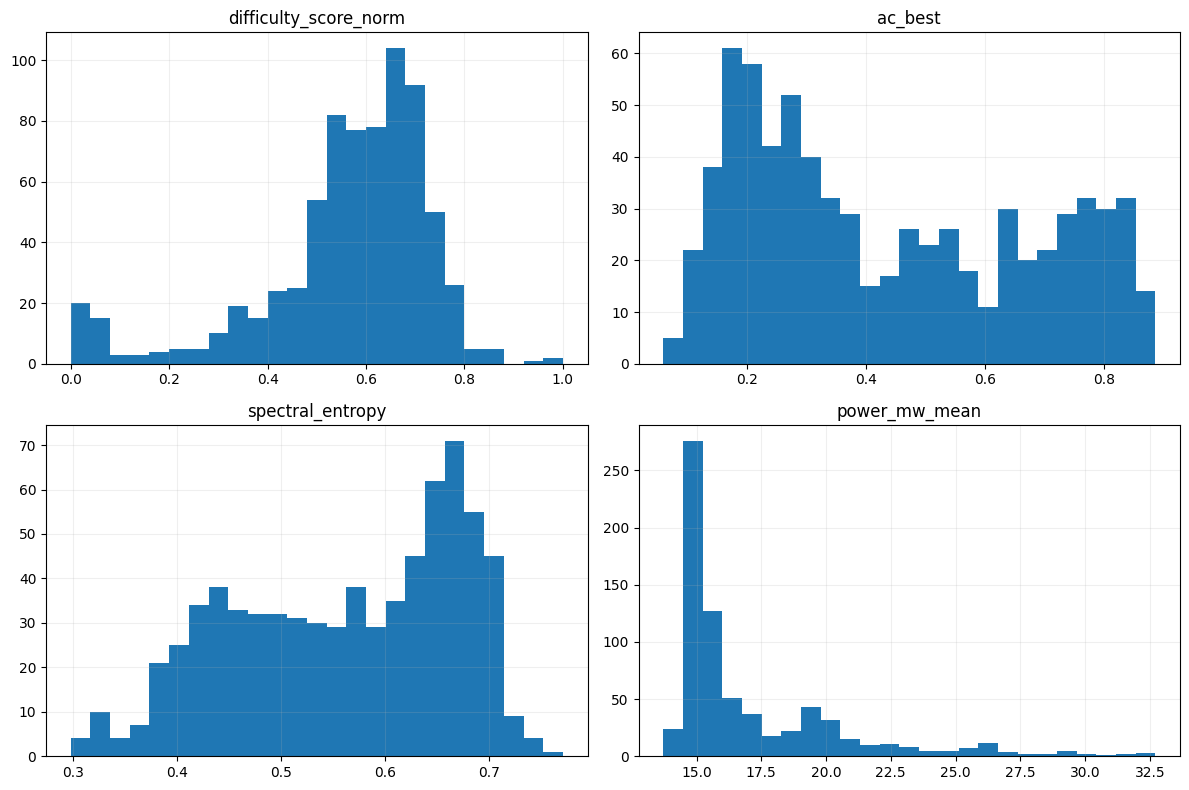

In [26]:
# Simple quality gates cho log thật (mục tiêu: compatibility/stability, không phải accuracy)

quality_df = feature_df.copy()

quality_df["gate_ir_dynamic"] = quality_df["ir_raw_ptp"] > 800

quality_df["gate_peak_rate"] = quality_df["peak_rate_per_sec"].between(40/60, 180/60)

quality_df["gate_ac"] = quality_df["ac_best"] > 0.15

quality_df["gate_entropy"] = quality_df["spectral_entropy"] < 0.95



quality_df["quality_pass"] = (

    quality_df["gate_ir_dynamic"] &

    quality_df["gate_peak_rate"] &

    quality_df["gate_ac"] &

    quality_df["gate_entropy"]

)



gate_summary = pd.DataFrame({

    "gate": ["ir_dynamic", "peak_rate", "ac", "entropy", "all_pass"],

    "pass_ratio": [

        quality_df["gate_ir_dynamic"].mean(),

        quality_df["gate_peak_rate"].mean(),

        quality_df["gate_ac"].mean(),

        quality_df["gate_entropy"].mean(),

        quality_df["quality_pass"].mean(),

    ]

})

display(gate_summary)



profile_quality = quality_df.groupby(["profile_name", "condition"]).agg(

    windows=("quality_pass", "count"),

    quality_pass_ratio=("quality_pass", "mean"),

    power_mw_mean=("power_mw_mean", "mean"),

    difficulty_mean=("difficulty_score_norm", "mean"),

    ac_best_mean=("ac_best", "mean"),

    ir_ptp_mean=("ir_raw_ptp", "mean"),

).reset_index().sort_values(["profile_name", "condition"])



print("=== Profile-condition quality map ===")

display(profile_quality)



fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes = axes.ravel()



axes[0].hist(feature_df["difficulty_score_norm"], bins=25)

axes[0].set_title("difficulty_score_norm")

axes[0].grid(alpha=0.2)



axes[1].hist(feature_df["ac_best"], bins=25)

axes[1].set_title("ac_best")

axes[1].grid(alpha=0.2)



axes[2].hist(feature_df["spectral_entropy"], bins=25)

axes[2].set_title("spectral_entropy")

axes[2].grid(alpha=0.2)



axes[3].hist(feature_df["power_mw_mean"], bins=25)

axes[3].set_title("power_mw_mean")

axes[3].grid(alpha=0.2)



plt.tight_layout()

plt.show()

In [29]:
# Compare firmware-like proxies: old (std+ptp) vs new (ac+ptp)
quality_df["difficulty_old_fw_like"] = 1.0 - 0.5 * (
    np.clip(quality_df["ir_raw_std"] / 4000.0, 0.0, 1.0) +
    np.clip(quality_df["ir_raw_ptp"] / 12000.0, 0.0, 1.0)
)

quality_df["difficulty_new_fw_like"] = (
    0.7 * (1.0 - np.clip(quality_df["ac_best"], 0.0, 1.0)) +
    0.3 * (1.0 - np.clip(quality_df["ir_raw_ptp"] / 6000.0, 0.0, 1.0))
)

proxy_cmp = quality_df.groupby("condition")[[
    "difficulty_old_fw_like",
    "difficulty_new_fw_like",
    "difficulty_score_norm",
    "ac_best",
    "ir_raw_ptp",
]].agg(["mean", "std"])

print("=== Proxy comparison by condition ===")
display(proxy_cmp)

corr_cols = ["difficulty_old_fw_like", "difficulty_new_fw_like", "difficulty_score_norm", "quality_pass", "ac_best", "ir_raw_ptp"]
proxy_corr = quality_df[corr_cols].corr(numeric_only=True)
print("\n=== Correlation matrix ===")
display(proxy_corr)

=== Proxy comparison by condition ===


difficulty_old_fw_like           difficulty_new_fw_like            \
                            mean       std                   mean       std   
condition                                                                     
bad                     0.002268  0.018346               0.518837  0.078835   
good                    0.630473  0.240940               0.363240  0.108363   

          difficulty_score_norm             ac_best              ir_raw_ptp  \
                           mean       std      mean       std          mean   
condition                                                                     
bad                    0.579643  0.132929  0.258804  0.112621  99276.584022   
good                   0.548386  0.210956  0.612709  0.190568   6578.310249   

                         
                    std  
condition                
bad        28563.924150  
good        9271.581462


=== Correlation matrix ===


,difficulty_old_fw_like,difficulty_new_fw_like,difficulty_score_norm,quality_pass,ac_best,ir_raw_ptp
difficulty_old_fw_like,1.000000,-0.626941,-0.112768,0.245329,0.838670,-0.848595
difficulty_new_fw_like,-0.626941,1.000000,0.089668,-0.399007,-0.924206,0.595180
difficulty_score_norm,-0.112768,0.089668,1.000000,0.074578,-0.125024,0.097736
quality_pass,0.245329,-0.399007,0.074578,1.000000,0.373906,-0.190964
ac_best,0.838670,-0.924206,-0.125024,0.373906,1.000000,-0.714457
ir_raw_ptp,-0.848595,0.595180,0.097736,-0.190964,-0.714457,1.000000


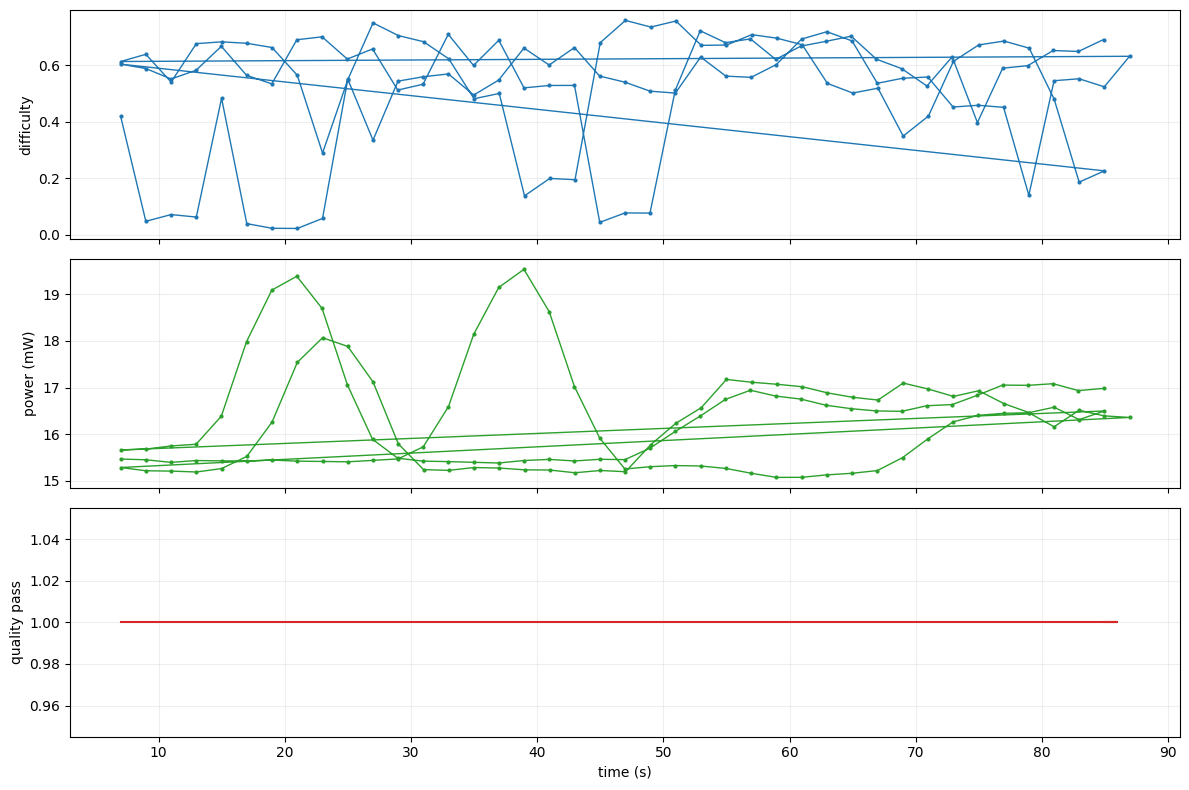

{'num_files': 18, 'total_rows_raw': 40830, 'total_windows': 724, 'overall_quality_pass_ratio': 0.9267955801104972, 'profiles': ['100sps_med', '50sps_med', 'adaptive_50_100']}


In [27]:
# Timeline quick-look cho 1 run tiêu biểu

VIEW_PROFILE = "50sps_med"

VIEW_CONDITION = "good"



candidate = quality_df[(quality_df["profile_name"] == VIEW_PROFILE) & (quality_df["condition"] == VIEW_CONDITION)].copy()

if len(candidate) == 0:

    candidate = quality_df.copy()



view_df = candidate.sort_values(["file_name", "window_start_s"]).copy().reset_index(drop=True)

view_df["window_mid_s"] = (view_df["window_start_s"] + view_df["window_end_s"]) / 2.0



fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(view_df["window_mid_s"], view_df["difficulty_score_norm"], marker="o", markersize=2, linewidth=1)

axes[0].set_ylabel("difficulty")

axes[0].grid(alpha=0.2)



axes[1].plot(view_df["window_mid_s"], view_df["power_mw_mean"], marker="o", markersize=2, linewidth=1, color="tab:green")

axes[1].set_ylabel("power (mW)")

axes[1].grid(alpha=0.2)



axes[2].step(view_df["window_mid_s"], view_df["quality_pass"].astype(int), where="mid", color="tab:red")

axes[2].set_ylabel("quality pass")

axes[2].set_xlabel("time (s)")

axes[2].grid(alpha=0.2)



plt.tight_layout()

plt.show()



summary = {

    "num_files": int(file_stats_df.shape[0]),

    "total_rows_raw": int(len(raw_df)),

    "total_windows": int(len(feature_df)),

    "overall_quality_pass_ratio": float(quality_df["quality_pass"].mean()),

    "profiles": sorted(quality_df["profile_name"].unique().tolist()),

}

print(summary)

In [30]:
# Policy analysis for firmware v2 profile set (fallback-friendly)
preferred_profiles = ["50sps_low", "50sps_med", "100sps_med"]
available_profiles = sorted(quality_df["profile_name"].unique().tolist())
POLICY_PROFILES = [p for p in preferred_profiles if p in available_profiles]
if len(POLICY_PROFILES) < 2:
    POLICY_PROFILES = available_profiles

policy_df = quality_df[quality_df["profile_name"].isin(POLICY_PROFILES)].copy()

print("=== Policy map (window-level) ===")
policy_map_df = policy_df.groupby(["profile_name", "condition"]).agg(
    windows=("quality_pass", "size"),
    quality_pass_ratio=("quality_pass", "mean"),
    avg_power_mw=("power_mw_mean", "mean"),
    difficulty_mean=("difficulty_score_norm", "mean"),
    ac_best_mean=("ac_best", "mean"),
    ir_ptp_mean=("ir_raw_ptp", "mean"),
).reset_index().sort_values(["profile_name", "condition"])
display(policy_map_df)

# Run-level stats để báo cáo mean ± std theo nhiều run
run_level_df = policy_df.groupby(["profile_name", "condition", "run_idx", "file_name"]).agg(
    windows=("quality_pass", "size"),
    quality_pass_ratio=("quality_pass", "mean"),
    avg_power_mw=("power_mw_mean", "mean"),
    difficulty_mean=("difficulty_score_norm", "mean"),
).reset_index()

report_stats_df = run_level_df.groupby(["profile_name", "condition"]).agg(
    n_runs=("run_idx", "nunique"),
    windows_mean=("windows", "mean"),
    quality_pass_ratio_mean=("quality_pass_ratio", "mean"),
    quality_pass_ratio_std=("quality_pass_ratio", "std"),
    avg_power_mw_mean=("avg_power_mw", "mean"),
    avg_power_mw_std=("avg_power_mw", "std"),
    difficulty_mean_mean=("difficulty_mean", "mean"),
    difficulty_mean_std=("difficulty_mean", "std"),
).reset_index().sort_values(["profile_name", "condition"])

print("\n=== Report table (mean ± std over runs) ===")
display(report_stats_df)

decision3_df = policy_map_df[[
    "profile_name", "condition", "quality_pass_ratio", "avg_power_mw", "difficulty_mean", "windows"
]].copy()

good_rank3 = decision3_df[decision3_df["condition"] == "good"].sort_values(
    ["quality_pass_ratio", "avg_power_mw", "difficulty_mean"],
    ascending=[False, True, True]
).reset_index(drop=True)

bad_rank3 = decision3_df[decision3_df["condition"] == "bad"].sort_values(
    ["quality_pass_ratio", "difficulty_mean", "avg_power_mw"],
    ascending=[False, True, True]
).reset_index(drop=True)

print("\n=== Good ranking (available profiles) ===")
display(good_rank3)

print("=== Bad robustness ranking (available profiles) ===")
display(bad_rank3)

print("=== Firmware v2 direction: adaptive stays 2-state (50sps_med <-> 100sps_med), 50sps_low kept as fixed candidate ===")

=== Policy map (window-level) ===


,profile_name,condition,windows,quality_pass_ratio,avg_power_mw,difficulty_mean,ac_best_mean,ir_ptp_mean
0,100sps_med,bad,122,0.885246,18.854519,0.585387,0.278520,118088.500000
1,100sps_med,good,120,1.000000,19.560650,0.657296,0.571174,7762.241667
2,50sps_med,bad,120,0.850000,15.425213,0.557339,0.229400,87569.516667
3,50sps_med,good,121,1.000000,16.223762,0.527261,0.612540,4227.859504



=== Report table (mean ± std over runs) ===


,profile_name,condition,n_runs,windows_mean,quality_pass_ratio_mean,quality_pass_ratio_std,avg_power_mw_mean,avg_power_mw_std,difficulty_mean_mean,difficulty_mean_std
0,100sps_med,bad,3,40.666667,0.885772,0.055623,18.862115,1.317657,0.585195,0.021605
1,100sps_med,good,3,40.000000,1.000000,0.000000,19.560650,0.220257,0.657296,0.062426
2,50sps_med,bad,3,40.000000,0.850000,0.025000,15.425213,0.352681,0.557339,0.026807
3,50sps_med,good,3,40.333333,1.000000,0.000000,16.225715,0.235681,0.527858,0.062736



=== Good ranking (available profiles) ===


,profile_name,condition,quality_pass_ratio,avg_power_mw,difficulty_mean,windows
0,50sps_med,good,1.0,16.223762,0.527261,121
1,100sps_med,good,1.0,19.560650,0.657296,120


=== Bad robustness ranking (available profiles) ===


,profile_name,condition,quality_pass_ratio,avg_power_mw,difficulty_mean,windows
0,100sps_med,bad,0.885246,18.854519,0.585387,122
1,50sps_med,bad,0.850000,15.425213,0.557339,120


=== Firmware v2 direction: adaptive stays 2-state (50sps_med <-> 100sps_med), 50sps_low kept as fixed candidate ===


In [18]:
# Policy v1 spec (2-state) + threshold probe + threshold tuning
gate_probe_cols = ["ir_raw_std", "ir_raw_ptp", "ac_best", "difficulty_score_norm"]
threshold_probe = []
for col in gate_probe_cols:
    g = feature_df.groupby("condition")[col].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
    print(f"\n=== {col} by condition ===")
    display(g)

    good_q25 = float(feature_df.loc[feature_df["condition"] == "good", col].quantile(0.25))
    bad_q75 = float(feature_df.loc[feature_df["condition"] == "bad", col].quantile(0.75))
    threshold_probe.append({
        "feature": col,
        "good_q25": good_q25,
        "bad_q75": bad_q75,
    })

threshold_probe_df = pd.DataFrame(threshold_probe)
print("\n=== Threshold probe table (để tham chiếu khi chỉnh gate firmware) ===")
display(threshold_probe_df)

def simulate_two_state(policy_df, th_hard, th_easy, good_windows_to_down=3, cooldown_windows=1):
    base_profile = "50sps_med"
    high_profile = "100sps_med"
    sim_base = policy_df[policy_df["profile_name"] == base_profile].sort_values(["condition", "file_name", "window_start_s"]).reset_index(drop=True)
    if len(sim_base) == 0:
        return None

    lookup = policy_df[policy_df["profile_name"].isin([base_profile, high_profile])].groupby(["condition", "profile_name"]).agg(
        est_quality_pass=("quality_pass", "mean"),
        est_power_mw=("power_mw_mean", "mean"),
        est_difficulty=("difficulty_score_norm", "mean"),
    ).reset_index()

    lookup_q = {(r.condition, r.profile_name): float(r.est_quality_pass) for r in lookup.itertuples()}
    lookup_p = {(r.condition, r.profile_name): float(r.est_power_mw) for r in lookup.itertuples()}
    lookup_d = {(r.condition, r.profile_name): float(r.est_difficulty) for r in lookup.itertuples()}

    state = base_profile
    good_count = 0
    cooldown = 0
    rows = []

    for r in sim_base.itertuples():
        cond = r.condition
        diff = float(r.difficulty_score_norm)
        qpass = bool(r.quality_pass)
        switched = False

        if cooldown > 0:
            cooldown -= 1
        else:
            if state == base_profile:
                if (not qpass) or (diff >= th_hard):
                    state = high_profile
                    switched = True
                    good_count = 0
            else:
                if qpass and diff <= th_easy:
                    good_count += 1
                    if good_count >= good_windows_to_down:
                        state = base_profile
                        switched = True
                        good_count = 0
                else:
                    good_count = 0

        if switched:
            cooldown = cooldown_windows

        rows.append({
            "selected_profile": state,
            "condition": cond,
            "est_quality_pass": lookup_q.get((cond, state), np.nan),
            "est_power_mw": lookup_p.get((cond, state), np.nan),
            "est_difficulty": lookup_d.get((cond, state), np.nan),
        })

    sim_df_local = pd.DataFrame(rows)
    sim_df_local["est_quality_pass"] = sim_df_local["est_quality_pass"].fillna(0.0)
    sim_df_local["est_power_mw"] = sim_df_local["est_power_mw"].fillna(policy_df["power_mw_mean"].mean())
    sim_df_local["est_difficulty"] = sim_df_local["est_difficulty"].fillna(policy_df["difficulty_score_norm"].mean())

    base_q = float(policy_df[policy_df["profile_name"] == base_profile]["quality_pass"].mean())
    base_p = float(policy_df[policy_df["profile_name"] == base_profile]["power_mw_mean"].mean())
    high_p = float(policy_df[policy_df["profile_name"] == high_profile]["power_mw_mean"].mean())

    state_ratio = sim_df_local["selected_profile"].value_counts(normalize=True).to_dict()
    policy_power = float(sim_df_local["est_power_mw"].mean())
    policy_quality = float(sim_df_local["est_quality_pass"].mean())
    policy_diff = float(sim_df_local["est_difficulty"].mean())

    return {
        "difficulty_hard": float(th_hard),
        "difficulty_easy": float(th_easy),
        "downshift_good_windows": int(good_windows_to_down),
        "cooldown_windows": int(cooldown_windows),
        "policy_quality": policy_quality,
        "policy_power": policy_power,
        "policy_difficulty": policy_diff,
        "baseline_quality_50": base_q,
        "baseline_power_50": base_p,
        "baseline_power_100": high_p,
        "power_saving_vs_100_pct": 100.0 * (high_p - policy_power) / high_p if high_p > 1e-9 else np.nan,
        "power_delta_vs_50_pct": 100.0 * (policy_power - base_p) / base_p if base_p > 1e-9 else np.nan,
        "ratio_50": float(state_ratio.get(base_profile, 0.0)),
        "ratio_100": float(state_ratio.get(high_profile, 0.0)),
    }

# Tuning theo dữ liệu thật: ưu tiên quality không giảm quá mạnh so với fixed 50, rồi giảm power
candidates = []
for hard in [0.65, 0.70, 0.75, 0.80]:
    for easy in [0.45, 0.50, 0.55, 0.60]:
        if easy >= hard:
            continue
        for down_n in [2, 3, 4]:
            sim = simulate_two_state(policy_df, th_hard=hard, th_easy=easy, good_windows_to_down=down_n, cooldown_windows=1)
            if sim is not None:
                candidates.append(sim)

tuning_df = pd.DataFrame(candidates).sort_values(["policy_quality", "policy_power"], ascending=[False, True]).reset_index(drop=True)
display(tuning_df.head(12))

quality_floor = float(policy_df[policy_df["profile_name"] == "50sps_med"]["quality_pass"].mean()) - 0.02
feasible = tuning_df[tuning_df["policy_quality"] >= quality_floor].copy()

if len(feasible):
    best_row = feasible.sort_values(["policy_power", "policy_quality"], ascending=[True, False]).iloc[0]
else:
    best_row = tuning_df.iloc[0]

POLICY_V1_2STATE = {
    "state_normal": "50sps_med",
    "state_high": "100sps_med",
    "window_sec": 8.0,
    "stride_sec": 2.0,
    "difficulty_hard": float(best_row["difficulty_hard"]),
    "difficulty_easy": float(best_row["difficulty_easy"]),
    "upshift_on_quality_fail": True,
    "downshift_good_windows": int(best_row["downshift_good_windows"]),
    "cooldown_windows_after_switch": int(best_row["cooldown_windows"]),
}

print("\n=== Selected POLICY_V1_2STATE ===")
display(POLICY_V1_2STATE)


=== ir_raw_std by condition ===


,count,mean,std,min,10%,25%,50%,75%,90%,max
condition,,,,,,,,,,
bad,226.0,19475.420961,10059.141289,5289.898438,7705.735596,9462.110352,18888.867188,27307.328613,33468.179688,43295.738281
good,225.0,622.606491,466.724259,58.141155,79.307889,195.425415,542.894958,942.726013,1268.254541,2096.151611



=== ir_raw_ptp by condition ===


,count,mean,std,min,10%,25%,50%,75%,90%,max
condition,,,,,,,,,,
bad,226.0,82069.185841,39224.859000,22858.0,34511.0,39571.0,83418.0,117099.75,140055.0,150562.0
good,225.0,2878.662222,2139.057353,274.0,377.0,907.0,2539.0,4310.00,5520.8,10344.0



=== ac_best by condition ===


...


=== Threshold probe table (để tham chiếu khi chỉnh gate firmware) ===


,feature,good_q25,bad_q75
0,ir_raw_std,195.425415,27307.328613
1,ir_raw_ptp,907.000000,117099.750000
2,ac_best,0.643803,0.285751
3,difficulty_score_norm,0.488082,0.735195


,difficulty_hard,difficulty_easy,downshift_good_windows,cooldown_windows,policy_quality,policy_power,policy_difficulty,baseline_quality_50,baseline_power_50,baseline_power_100,power_saving_vs_100_pct,power_delta_vs_50_pct,ratio_50,ratio_100
0,0.80,0.60,2,1,0.925600,16.524783,0.577512,0.94,13.948739,19.334615,14.532651,18.467939,0.533333,0.466667
1,0.75,0.60,2,1,0.924589,16.743099,0.575328,0.94,13.948739,19.334615,13.403502,20.033073,0.493333,0.506667
2,0.70,0.60,2,1,0.923326,17.102280,0.572772,0.94,13.948739,19.334615,11.545796,22.608075,0.426667,0.573333
3,0.65,0.60,2,1,0.923326,17.378391,0.573328,0.94,13.948739,19.334615,10.117731,24.587544,0.373333,0.626667
4,0.80,0.55,2,1,0.921053,17.231096,0.567130,0.94,13.948739,19.334615,10.879549,23.531572,0.406667,0.593333
5,0.80,0.60,3,1,0.921053,17.265610,0.567200,0.94,13.948739,19.334615,10.701041,23.779006,0.400000,0.600000
6,0.75,0.55,2,1,0.921053,17.300124,0.567269,0.94,13.948739,19.334615,10.522533,24.026440,0.393333,0.606667
7,0.80,0.55,3,1,0.921053,17.300124,0.567269,0.94,13.948739,19.334615,10.522533,24.026440,0.393333,0.606667
8,0.75,0.60,3,1,0.921053,17.334638,0.567339,0.94,13.948739,19.334615,10.344025,24.273874,0.386667,0.613333
9,0.80,0.60,4,1,0.921053,17.334638,0.567339,0.94,13.948739,19.334615,10.344025,24.273874,0.386667,0.613333



=== Selected POLICY_V1_2STATE ===


{'state_normal': '50sps_med',
 'state_high': '100sps_med',
 'window_sec': 8.0,
 'stride_sec': 2.0,
 'difficulty_hard': 0.8,
 'difficulty_easy': 0.6,
 'upshift_on_quality_fail': True,
 'downshift_good_windows': 2,
 'cooldown_windows_after_switch': 1}

In [19]:
# Scheduler simulation v1 (2-state: 50sps_med <-> 100sps_med, using tuned POLICY_V1_2STATE)
BASE_PROFILE = POLICY_V1_2STATE["state_normal"]
HIGH_PROFILE = POLICY_V1_2STATE["state_high"]
TH_HARD = float(POLICY_V1_2STATE["difficulty_hard"])
TH_EASY = float(POLICY_V1_2STATE["difficulty_easy"])
GOOD_WINDOWS_TO_DOWN = int(POLICY_V1_2STATE["downshift_good_windows"])
COOLDOWN_WINDOWS = int(POLICY_V1_2STATE["cooldown_windows_after_switch"])

sim_base = policy_df[(policy_df["profile_name"] == BASE_PROFILE)].copy()
sim_base = sim_base.sort_values(["condition", "file_name", "window_start_s"]).reset_index(drop=True)
assert len(sim_base) > 0, "Không có window từ 50sps_med để mô phỏng scheduler"

lookup = policy_df[policy_df["profile_name"].isin([BASE_PROFILE, HIGH_PROFILE])].groupby(["condition", "profile_name"]).agg(
    est_quality_pass=("quality_pass", "mean"),
    est_power_mw=("power_mw_mean", "mean"),
    est_difficulty=("difficulty_score_norm", "mean"),
).reset_index()

lookup_q = {(r.condition, r.profile_name): float(r.est_quality_pass) for r in lookup.itertuples()}
lookup_p = {(r.condition, r.profile_name): float(r.est_power_mw) for r in lookup.itertuples()}
lookup_d = {(r.condition, r.profile_name): float(r.est_difficulty) for r in lookup.itertuples()}

state = BASE_PROFILE
good_count = 0
cooldown = 0
sim_rows = []

for r in sim_base.itertuples():
    cond = r.condition
    diff = float(r.difficulty_score_norm)
    qpass = bool(r.quality_pass)
    switched = False

    if cooldown > 0:
        cooldown -= 1
    else:
        if state == BASE_PROFILE:
            if (not qpass) or (diff >= TH_HARD):
                state = HIGH_PROFILE
                switched = True
                good_count = 0
        else:
            if qpass and diff <= TH_EASY:
                good_count += 1
                if good_count >= GOOD_WINDOWS_TO_DOWN:
                    state = BASE_PROFILE
                    switched = True
                    good_count = 0
            else:
                good_count = 0

    if switched:
        cooldown = COOLDOWN_WINDOWS

    sim_rows.append({
        "condition": cond,
        "file_name": r.file_name,
        "window_start_s": float(r.window_start_s),
        "driver_difficulty": diff,
        "driver_quality_pass": int(qpass),
        "selected_profile": state,
        "est_quality_pass": lookup_q.get((cond, state), np.nan),
        "est_power_mw": lookup_p.get((cond, state), np.nan),
        "est_difficulty": lookup_d.get((cond, state), np.nan),
    })

sim_df = pd.DataFrame(sim_rows)
sim_df["est_quality_pass"] = sim_df["est_quality_pass"].fillna(0.0)
sim_df["est_power_mw"] = sim_df["est_power_mw"].fillna(policy_df["power_mw_mean"].mean())
sim_df["est_difficulty"] = sim_df["est_difficulty"].fillna(policy_df["difficulty_score_norm"].mean())

state_ratio = sim_df["selected_profile"].value_counts(normalize=True).rename("time_ratio").reset_index()
state_ratio.columns = ["selected_profile", "time_ratio"]

profile_power = policy_df.groupby("profile_name")["power_mw_mean"].mean().to_dict()
policy_avg_power = float(sim_df["est_power_mw"].mean())
fixed_power_50 = float(profile_power.get(BASE_PROFILE, np.nan))
fixed_power_100 = float(profile_power.get(HIGH_PROFILE, np.nan))

saving_vs_100_pct = 100.0 * (fixed_power_100 - policy_avg_power) / fixed_power_100 if np.isfinite(fixed_power_100) and fixed_power_100 > 1e-9 else np.nan
delta_vs_50_pct = 100.0 * (policy_avg_power - fixed_power_50) / fixed_power_50 if np.isfinite(fixed_power_50) and fixed_power_50 > 1e-9 else np.nan

sim_summary = pd.DataFrame([{
    "windows": int(len(sim_df)),
    "estimated_quality_pass_ratio_under_policy": float(sim_df["est_quality_pass"].mean()),
    "estimated_difficulty_under_policy": float(sim_df["est_difficulty"].mean()),
    "policy_avg_power_mw": policy_avg_power,
    "fixed_50_avg_power_mw": fixed_power_50,
    "fixed_100_avg_power_mw": fixed_power_100,
    "power_saving_vs_fixed100_pct": float(saving_vs_100_pct),
    "power_delta_vs_fixed50_pct": float(delta_vs_50_pct),
}])

print("=== Selected policy params ===")
print(POLICY_V1_2STATE)

print("\n=== Scheduler v1 (2-state) state ratio ===")
display(state_ratio)

print("=== Scheduler v1 (2-state) KPI summary ===")
display(sim_summary)

=== Selected policy params ===
{'state_normal': '50sps_med', 'state_high': '100sps_med', 'window_sec': 8.0, 'stride_sec': 2.0, 'difficulty_hard': 0.8, 'difficulty_easy': 0.6, 'upshift_on_quality_fail': True, 'downshift_good_windows': 2, 'cooldown_windows_after_switch': 1}

=== Scheduler v1 (2-state) state ratio ===


,selected_profile,time_ratio
0,50sps_med,0.533333
1,100sps_med,0.466667


=== Scheduler v1 (2-state) KPI summary ===


,windows,estimated_quality_pass_ratio_under_policy,estimated_difficulty_under_policy,policy_avg_power_mw,fixed_50_avg_power_mw,fixed_100_avg_power_mw,power_saving_vs_fixed100_pct,power_delta_vs_fixed50_pct
0,150,0.9256,0.577512,16.524783,13.948739,19.334615,14.532651,18.467939


In [28]:
# Experiment summary cho exp_v1_2state (fixed_50 vs fixed_100 vs adaptive)
exp_summary_df = quality_df.groupby(["exp_mode", "condition"]).agg(
    windows=("quality_pass", "size"),
    quality_pass_ratio=("quality_pass", "mean"),
    avg_power_mw=("power_mw_mean", "mean"),
    difficulty_mean=("difficulty_score_norm", "mean"),
    ac_best_mean=("ac_best", "mean"),
).reset_index().sort_values(["condition", "exp_mode"])
,
print("=== A/B/C summary by mode-condition ===")
display(exp_summary_df)

adaptive_rows = raw_df[raw_df["exp_mode"] == "adaptive"].copy()
adaptive_rows = adaptive_rows[adaptive_rows["state_id"] >= 0].copy()

if len(adaptive_rows) > 0:
    adaptive_state_ratio = adaptive_rows.groupby(["condition", "state_id"]).size().rename("rows").reset_index()
    adaptive_state_ratio["time_ratio"] = adaptive_state_ratio.groupby("condition")["rows"].transform(lambda x: x / x.sum())
    state_name_map = {0: "normal(50sps)", 1: "high(100sps)"}
    adaptive_state_ratio["state_name"] = adaptive_state_ratio["state_id"].map(state_name_map).fillna("unknown")

    print("\n=== Adaptive state occupancy (from on-device logs) ===")
    display(adaptive_state_ratio[["condition", "state_id", "state_name", "rows", "time_ratio"]])
else:
    print("\nKhông có state_id hợp lệ trong adaptive logs để tính occupancy")

power_pivot = exp_summary_df.pivot(index="condition", columns="exp_mode", values="avg_power_mw")
quality_pivot = exp_summary_df.pivot(index="condition", columns="exp_mode", values="quality_pass_ratio")

if {"fixed_100", "adaptive"}.issubset(set(power_pivot.columns)):
    compare_df = pd.DataFrame(index=power_pivot.index)
    compare_df["adaptive_power_vs_fixed100_saving_pct"] = 100.0 * (power_pivot["fixed_100"] - power_pivot["adaptive"]) / power_pivot["fixed_100"]
    if "fixed_50" in power_pivot.columns:
        compare_df["adaptive_power_vs_fixed50_delta_pct"] = 100.0 * (power_pivot["adaptive"] - power_pivot["fixed_50"]) / power_pivot["fixed_50"]
    if {"fixed_100", "adaptive"}.issubset(set(quality_pivot.columns)):
        compare_df["adaptive_quality_minus_fixed100"] = quality_pivot["adaptive"] - quality_pivot["fixed_100"]
    if "fixed_50" in quality_pivot.columns:
        compare_df["adaptive_quality_minus_fixed50"] = quality_pivot["adaptive"] - quality_pivot["fixed_50"]

    print("\n=== Adaptive benefit/penalty vs baselines ===")
    display(compare_df.reset_index())

=== A/B/C summary by mode-condition ===


,exp_mode,condition,windows,quality_pass_ratio,avg_power_mw,difficulty_mean,ac_best_mean
0,adaptive,bad,121,0.909091,15.041657,0.595972,0.268085
2,fixed_100,bad,122,0.885246,18.854519,0.585387,0.278520
4,fixed_50,bad,120,0.850000,15.425213,0.557339,0.229400
1,adaptive,good,120,0.916667,17.867459,0.460776,0.654413
3,fixed_100,good,120,1.000000,19.560650,0.657296,0.571174
5,fixed_50,good,121,1.000000,16.223762,0.527261,0.612540



=== Adaptive state occupancy (from on-device logs) ===


,condition,state_id,state_name,rows,time_ratio
0,bad,0,normal(50sps),6224,0.912075
1,bad,1,high(100sps),600,0.087925
2,good,0,normal(50sps),797,0.117638
3,good,1,high(100sps),5978,0.882362



=== Adaptive benefit/penalty vs baselines ===


,condition,adaptive_power_vs_fixed100_saving_pct,adaptive_power_vs_fixed50_delta_pct,adaptive_quality_minus_fixed100,adaptive_quality_minus_fixed50
0,bad,20.222533,-2.486549,0.023845,0.059091
1,good,8.656107,10.131414,-0.083333,-0.083333
